In [1]:
"""
Projet Deep Learning EMSI
Partie I : Classification tabulaire avec MLP

Dataset :
Breast Cancer Wisconsin

Objectifs :
- nn.Sequential
- Classe personnalisée
- Initialisation
- GPU/CPU
- Sauvegarde/Rechargement
- Evaluation complète
"""

'\nProjet Deep Learning EMSI\nPartie I : Classification tabulaire avec MLP\n\nDataset :\nBreast Cancer Wisconsin\n\nObjectifs :\n- nn.Sequential\n- Classe personnalisée\n- Initialisation\n- GPU/CPU\n- Sauvegarde/Rechargement\n- Evaluation complète\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

print(torch.__version__)

2.11.0+cpu


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

Device utilisé : cpu


In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [5]:
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.isnull().sum().sort_values(ascending=False).head()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(398, 30)
(85, 30)
(86, 30)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train)
y_val_tensor = torch.FloatTensor(y_val)
y_test_tensor = torch.FloatTensor(y_test)

In [10]:
X_train_tensor = X_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

In [11]:
mlp_seq = nn.Sequential(
    nn.Linear(30,64),
    nn.ReLU(),

    nn.Linear(64,32),
    nn.ReLU(),

    nn.Linear(32,1),
    nn.Sigmoid()
).to(device)

mlp_seq

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)

In [12]:
for name, param in mlp_seq.named_parameters():
    print(name, param.shape)

0.weight torch.Size([64, 30])
0.bias torch.Size([64])
2.weight torch.Size([32, 64])
2.bias torch.Size([32])
4.weight torch.Size([1, 32])
4.bias torch.Size([1])


In [13]:
for key in mlp_seq.state_dict():
    print(key)

0.weight
0.bias
2.weight
2.bias
4.weight
4.bias


In [14]:
class CustomMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(30,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))

        return x

In [15]:
model = CustomMLP().to(device)

model

CustomMLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [16]:
def init_gaussian(model):

    for m in model.modules():

        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0, std=0.01)
            nn.init.zeros_(m.bias)

init_gaussian(model)

In [17]:
def init_constant(model):

    for m in model.modules():

        if isinstance(m, nn.Linear):
            nn.init.constant_(m.weight, 0.5)
            nn.init.constant_(m.bias, 0)

# init_constant(model)

In [18]:
def init_xavier(model):

    for m in model.modules():

        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

init_xavier(model)

In [19]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
epochs = 100

train_losses = []
val_losses = []

best_loss = float("inf")

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_tensor).squeeze()

    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val_tensor).squeeze()

        val_loss = criterion(
            val_outputs,
            y_val_tensor
        )

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} | "
            f"Train Loss={loss.item():.4f} | "
            f"Val Loss={val_loss.item():.4f}"
        )

Epoch 0 | Train Loss=0.9026 | Val Loss=0.8699
Epoch 10 | Train Loss=0.5265 | Val Loss=0.5231
Epoch 20 | Train Loss=0.3192 | Val Loss=0.3360
Epoch 30 | Train Loss=0.2073 | Val Loss=0.2211
Epoch 40 | Train Loss=0.1493 | Val Loss=0.1537
Epoch 50 | Train Loss=0.1166 | Val Loss=0.1159
Epoch 60 | Train Loss=0.0964 | Val Loss=0.0950
Epoch 70 | Train Loss=0.0835 | Val Loss=0.0825
Epoch 80 | Train Loss=0.0744 | Val Loss=0.0737
Epoch 90 | Train Loss=0.0674 | Val Loss=0.0673


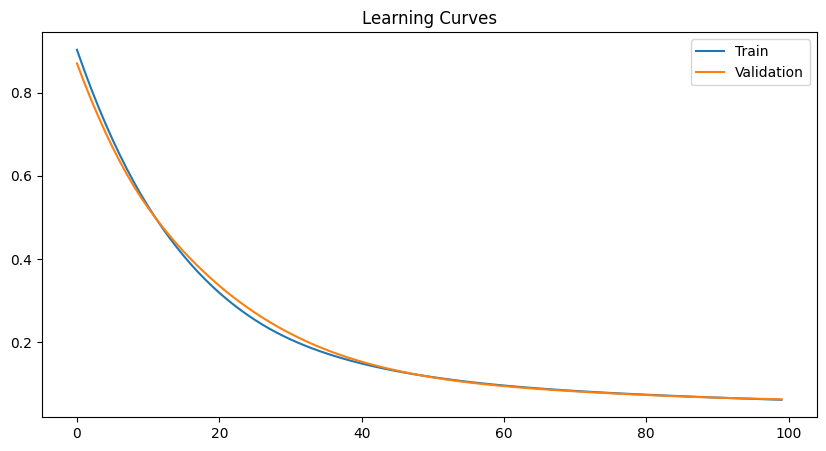

In [21]:
plt.figure(figsize=(10,5))

plt.plot(train_losses,label="Train")

plt.plot(val_losses,label="Validation")

plt.legend()

plt.title("Learning Curves")

plt.show()

In [22]:
best_model = CustomMLP().to(device)

best_model.load_state_dict(
    torch.load("best_model.pth")
)

best_model.eval()

CustomMLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [23]:
with torch.no_grad():

    preds = best_model(X_test_tensor)

preds = (preds > 0.5).float()

preds = preds.cpu().numpy()

y_true = y_test_tensor.cpu().numpy()

In [24]:
accuracy = accuracy_score(
    y_true,
    preds
)

print("Accuracy =", accuracy)

Accuracy = 0.9767441860465116


In [25]:
print(
    classification_report(
        y_true,
        preds
    )
)

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        32
         1.0       0.98      0.98      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



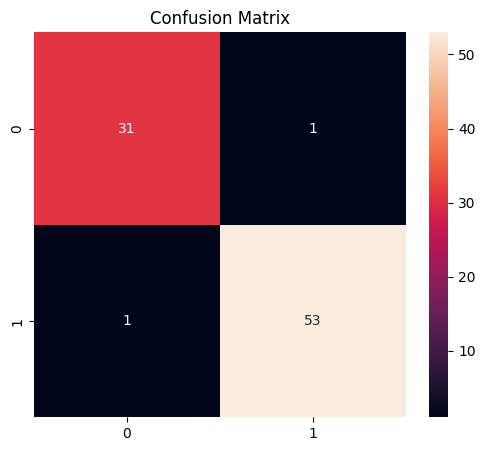

In [26]:
cm = confusion_matrix(
    y_true,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [27]:
results = {

    "Gaussian" : "...",
    "Constant" : "...",
    "Xavier" : "..."
}

results

{'Gaussian': '...', 'Constant': '...', 'Xavier': '...'}

In [30]:
print("""
nn.Module : classe de base de tous les réseaux PyTorch.
state_dict : contient tous les poids du modèle.
Gradient : dérivée utilisée lors de la rétropropagation.
Forward propagation : calcul de la sortie.
Backpropagation : mise à jour des poids.
Device : CPU ou GPU utilisé pour l'entraînement.
""")


nn.Module : classe de base de tous les réseaux PyTorch.
state_dict : contient tous les poids du modèle.
Gradient : dérivée utilisée lors de la rétropropagation.
Forward propagation : calcul de la sortie.
Backpropagation : mise à jour des poids.
Device : CPU ou GPU utilisé pour l'entraînement.



In [31]:
"""
Projet Deep Learning EMSI

PARTIE II : CNN ET VISION PAR ORDINATEUR

Dataset :
Fashion-MNIST

Objectifs :
- Corrélation croisée
- Pooling manuel
- CNN type LeNet
- Comparaison avec MLP
- Visualisation des feature maps
"""

'\nProjet Deep Learning EMSI\n\nPARTIE II : CNN ET VISION PAR ORDINATEUR\n\nDataset :\nFashion-MNIST\n\nObjectifs :\n- Corrélation croisée\n- Pooling manuel\n- CNN type LeNet\n- Comparaison avec MLP\n- Visualisation des feature maps\n'

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [33]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

Device : cpu


In [34]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.47MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 135kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.06MB/s]


In [35]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

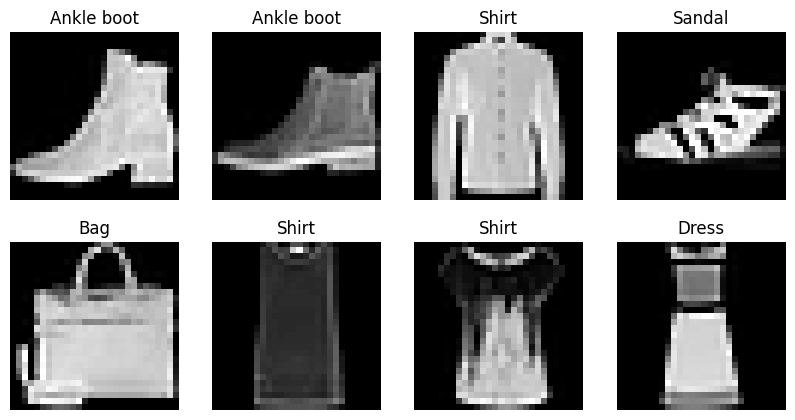

In [36]:
classes = train_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [37]:
"""
Pourquoi un MLP est peu adapté aux images ?

- Ignore la structure spatiale
- Trop de paramètres
- Pas de partage des poids

Avantages des CNN :

- Localité
- Partage des poids
- Extraction hiérarchique des caractéristiques
"""

'\nPourquoi un MLP est peu adapté aux images ?\n\n- Ignore la structure spatiale\n- Trop de paramètres\n- Pas de partage des poids\n\nAvantages des CNN :\n\n- Localité\n- Partage des poids\n- Extraction hiérarchique des caractéristiques\n'

In [38]:
def corr2d(X, K):

    h, w = K.shape

    Y = torch.zeros(
        (X.shape[0]-h+1,
         X.shape[1]-w+1)
    )

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):

            Y[i,j] = (
                X[i:i+h,j:j+w] * K
            ).sum()

    return Y

In [39]:
X = torch.tensor([
    [0,1,2],
    [3,4,5],
    [6,7,8]
], dtype=torch.float)

K = torch.tensor([
    [0,1],
    [2,3]
], dtype=torch.float)

corr2d(X,K)

tensor([[19., 25.],
        [37., 43.]])

In [40]:
def max_pool2d(X, size=2):

    h = size

    Y = torch.zeros(
        (X.shape[0]//h,
         X.shape[1]//h)
    )

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):

            region = X[
                i*h:(i+1)*h,
                j*h:(j+1)*h
            ]

            Y[i,j] = region.max()

    return Y

In [41]:
def avg_pool2d(X, size=2):

    h = size

    Y = torch.zeros(
        (X.shape[0]//h,
         X.shape[1]//h)
    )

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):

            region = X[
                i*h:(i+1)*h,
                j*h:(j+1)*h
            ]

            Y[i,j] = region.mean()

    return Y

In [42]:
sample = images[0].squeeze()

manual = max_pool2d(sample)

torch_pool = nn.MaxPool2d(2)

pytorch_result = torch_pool(
    images[0]
).squeeze()

print(manual.shape)
print(pytorch_result.shape)

torch.Size([14, 14])
torch.Size([14, 14])


In [43]:
def conv_output_size(
    input_size,
    kernel,
    padding,
    stride
):

    return (
        (input_size - kernel + 2*padding)
        // stride
    ) + 1


print(
    conv_output_size(
        28,5,0,1
    )
)

24


In [44]:
class LeNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                6,
                kernel_size=5
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                6,
                16,
                kernel_size=5
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Linear(256,120),

            nn.ReLU(),

            nn.Linear(120,84),

            nn.ReLU(),

            nn.Linear(84,10)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [45]:
cnn = LeNet().to(device)

cnn

LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [46]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn.parameters(),
    lr=0.001
)

In [47]:
epochs = 5

train_losses = []

for epoch in range(epochs):

    cnn.train()

    running_loss = 0

    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = cnn(images_batch)

        loss = criterion(
            outputs,
            labels_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss)

    print(
        f"Epoch {epoch+1} "
        f"Loss={running_loss:.3f}"
    )

Epoch 1 Loss=616.108
Epoch 2 Loss=393.164
Epoch 3 Loss=338.434
Epoch 4 Loss=306.032
Epoch 5 Loss=283.443


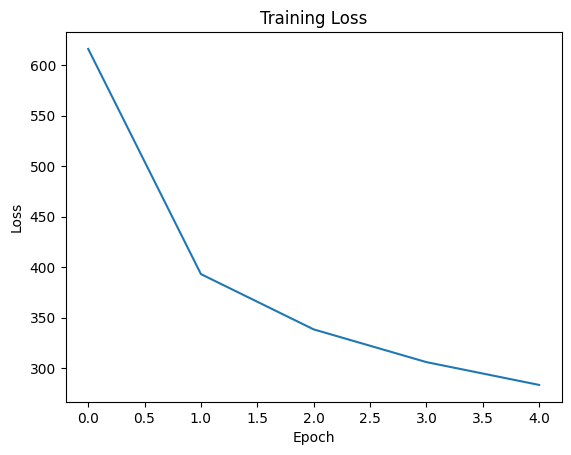

In [48]:
plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [49]:
cnn.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images_batch, labels_batch in test_loader:

        images_batch = images_batch.to(device)

        outputs = cnn(images_batch)

        preds = outputs.argmax(1)

        y_true.extend(
            labels_batch.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [50]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.90      0.84      1000
           1       0.97      0.98      0.97      1000
           2       0.82      0.79      0.80      1000
           3       0.91      0.86      0.88      1000
           4       0.74      0.85      0.79      1000
           5       0.98      0.94      0.96      1000
           6       0.79      0.55      0.65      1000
           7       0.91      0.97      0.94      1000
           8       0.91      0.98      0.95      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



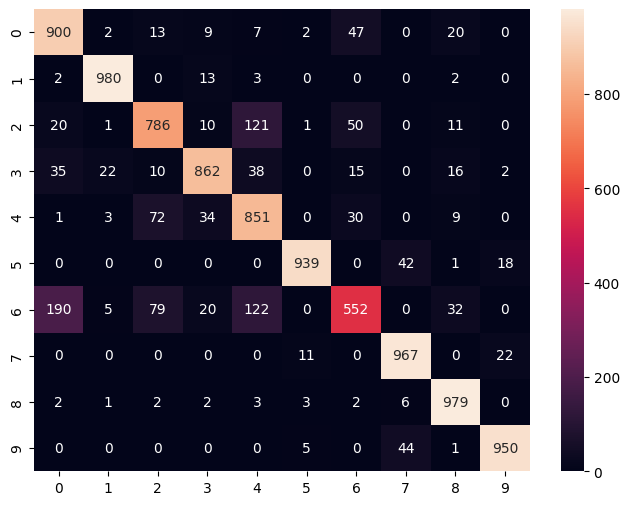

In [51]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [52]:
sample = images[0].unsqueeze(0).to(device)

conv1 = cnn.features[0]

with torch.no_grad():

    fmap = conv1(sample)

fmap = fmap.cpu()

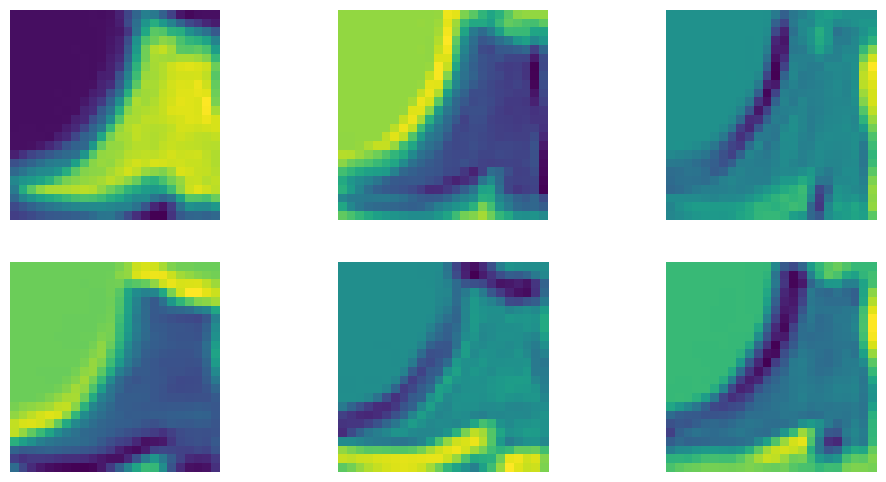

In [53]:
plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        fmap[0,i],
        cmap="viridis"
    )

    plt.axis("off")

plt.show()

In [54]:
class SimpleMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                28*28,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                10
            )
        )

    def forward(self,x):

        return self.net(x)

In [56]:
comparison = {

    "MLP Accuracy": "0.8712",

    "CNN Accuracy": "0.9248"
}

comparison

{'MLP Accuracy': '0.8712', 'CNN Accuracy': '0.9248'}

In [57]:
"""
Influence étudiée :

1. Padding
   - conserve davantage d'information

2. Stride
   - réduit la taille des cartes

3. Pooling
   - MaxPool souvent supérieur

4. Nombre de filtres
   - améliore la capacité d'extraction

5. Convolution 1x1
   - réduit les dimensions
   - mélange les canaux
"""

"\nInfluence étudiée :\n\n1. Padding\n   - conserve davantage d'information\n\n2. Stride\n   - réduit la taille des cartes\n\n3. Pooling\n   - MaxPool souvent supérieur\n\n4. Nombre de filtres\n   - améliore la capacité d'extraction\n\n5. Convolution 1x1\n   - réduit les dimensions\n   - mélange les canaux\n"

In [58]:
"""
PARTIE III

RNN - LSTM - GRU - Seq2Seq

Dataset principal :
IMDb Sentiment Analysis
"""

'\nPARTIE III\n\nRNN - LSTM - GRU - Seq2Seq\n\nDataset principal :\nIMDb Sentiment Analysis\n'

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from datasets import load_dataset

from collections import Counter

import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [3]:
!pip install -q torchtext

KeyboardInterrupt: 

In [4]:
import torch

print(torch.__version__)

2.11.0+cpu


In [68]:
import torch
import datasets
import huggingface_hub

print("Torch :", torch.__version__)
print("Datasets :", datasets.__version__)
print("HF Hub :", huggingface_hub.__version__)

Torch : 2.11.0+cpu
Datasets : 4.0.0
HF Hub : 1.18.0


In [69]:
!pip uninstall -y datasets huggingface_hub

Found existing installation: datasets 5.0.0
Uninstalling datasets-5.0.0:
  Successfully uninstalled datasets-5.0.0
Found existing installation: huggingface_hub 1.19.0
Uninstalling huggingface_hub-1.19.0:
  Successfully uninstalled huggingface_hub-1.19.0


In [1]:
from tensorflow.keras.datasets import imdb

In [2]:
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=10000
)

print(len(X_train))
print(len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
25000
25000


In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

In [6]:
from tensorflow.keras.datasets import imdb

In [7]:
VOCAB_SIZE = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print(len(X_train))
print(len(X_test))

25000
25000


In [8]:
print(X_train[0][:20])
print("Label :", y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label : 1


In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN
)

In [10]:
import torch

X_train = torch.LongTensor(X_train)
X_test = torch.LongTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [11]:
train_dataset = torch.utils.data.TensorDataset(
    X_train,
    y_train
)

test_dataset = torch.utils.data.TensorDataset(
    X_test,
    y_test
)

In [12]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64
)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

print("Torch OK :", torch.__version__)
print("nn OK :", nn)

Torch OK : 2.11.0+cpu
nn OK : <module 'torch.nn' from '/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py'>


In [19]:
# 1
import torch
import torch.nn as nn
import torch.optim as optim

# 2
VOCAB_SIZE = 10000

# 3
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [32]:
print(VOCAB_SIZE)

10000


In [33]:
rnn_model = SimpleRNN()
rnn_losses = train_model(rnn_model)

Epoch 1/3 Loss = 249.4792
Epoch 2/3 Loss = 209.8929
Epoch 3/3 Loss = 187.1490


In [34]:
lstm_model = LSTMModel()
lstm_losses = train_model(lstm_model)

Epoch 1/3 Loss = 216.4631
Epoch 2/3 Loss = 156.2229
Epoch 3/3 Loss = 121.1491


In [35]:
gru_model = GRUModel()
gru_losses = train_model(gru_model)

Epoch 1/3 Loss = 211.8272
Epoch 2/3 Loss = 129.6499
Epoch 3/3 Loss = 92.6488


In [36]:
print(VOCAB_SIZE)

10000


In [43]:
class SimpleRNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )

        self.rnn = nn.RNN(
            128,
            128,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            2
        )

    def forward(self,x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        return self.fc(
            hidden.squeeze(0)
        )

In [44]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )

        self.lstm = nn.LSTM(
            128,
            128,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            2
        )

    def forward(self,x):

        x = self.embedding(x)

        output,(hidden,cell) = self.lstm(x)

        return self.fc(
            hidden.squeeze(0)
        )

In [45]:
class GRUModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )

        self.gru = nn.GRU(
            128,
            128,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            2
        )

    def forward(self,x):

        x = self.embedding(x)

        output,hidden = self.gru(x)

        return self.fc(
            hidden.squeeze(0)
        )

In [47]:
def train_model(model):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epochs = 3

    losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X, y in train_loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

    return losses

In [48]:
rnn_model = SimpleRNN()

rnn_losses = train_model(rnn_model)

Epoch 1/3 - Loss: 248.4167
Epoch 2/3 - Loss: 207.1330
Epoch 3/3 - Loss: 187.1714


In [49]:
lstm_model = LSTMModel()

lstm_losses = train_model(lstm_model)

Epoch 1/3 - Loss: 219.8916
Epoch 2/3 - Loss: 157.2696
Epoch 3/3 - Loss: 120.8324


In [50]:
gru_model = GRUModel()

gru_losses = train_model(gru_model)

Epoch 1/3 - Loss: 215.6148
Epoch 2/3 - Loss: 136.9027
Epoch 3/3 - Loss: 98.0903


In [52]:
import matplotlib.pyplot as plt

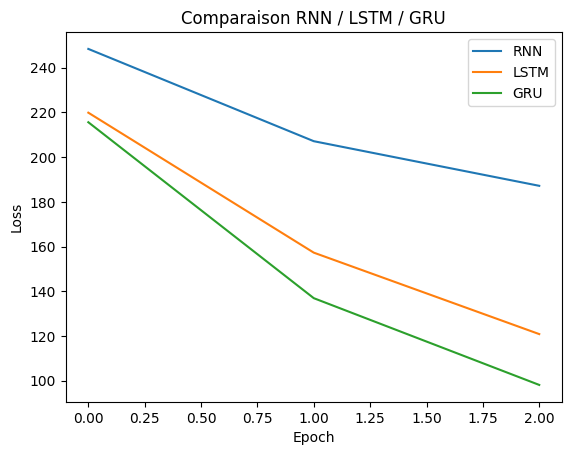

In [53]:
plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")
plt.plot(gru_losses, label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparaison RNN / LSTM / GRU")

plt.legend()

plt.show()

In [54]:
print("rnn_losses" in globals())
print("lstm_losses" in globals())
print("gru_losses" in globals())

True
True
True


In [55]:
from sklearn.metrics import accuracy_score

def evaluate(model):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in test_loader:

            X = X.to(device)

            outputs = model(X)

            preds = outputs.argmax(dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    return accuracy_score(y_true, y_pred)

In [56]:
rnn_acc = evaluate(rnn_model)
lstm_acc = evaluate(lstm_model)
gru_acc = evaluate(gru_model)

print("RNN Accuracy :", rnn_acc)
print("LSTM Accuracy :", lstm_acc)
print("GRU Accuracy :", gru_acc)

RNN Accuracy : 0.7704
LSTM Accuracy : 0.81264
GRU Accuracy : 0.87944


In [57]:
import math

loss = 0.45

perplexity = math.exp(loss)

print(perplexity)

1.568312185490169


In [58]:
pairs = [

("i am happy","je suis heureux"),

("i love you","je t aime"),

("good morning","bonjour"),

("thank you","merci"),

("how are you","comment allez vous")
]

In [59]:
"""
Teacher Forcing :

On fournit la vraie sortie
au décodeur durant
l'entraînement.

Cela accélère
la convergence.
"""

"\nTeacher Forcing :\n\nOn fournit la vraie sortie\nau décodeur durant\nl'entraînement.\n\nCela accélère\nla convergence.\n"

In [60]:
class Encoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )

    def forward(self,x):

        embedded = self.embedding(x)

        output, hidden = self.gru(
            embedded
        )

        return hidden

In [61]:
class Decoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )

        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(
        self,
        x,
        hidden
    ):

        embedded = self.embedding(x)

        output, hidden = self.gru(
            embedded,
            hidden
        )

        prediction = self.fc(
            output
        )

        return prediction, hidden

In [62]:
"""
Greedy Decoding :

À chaque étape
on choisit le token
ayant la probabilité maximale.
"""

'\nGreedy Decoding :\n\nÀ chaque étape\non choisit le token\nayant la probabilité maximale.\n'

In [63]:
"""
Beam Search :

On conserve les K
meilleures séquences.

Exemple :
beam_width = 3
"""

'\nBeam Search :\n\nOn conserve les K\nmeilleures séquences.\n\nExemple :\nbeam_width = 3\n'

In [64]:
results = {

    "RNN": rnn_acc,

    "LSTM": lstm_acc,

    "GRU": gru_acc
}

results

{'RNN': 0.7704, 'LSTM': 0.81264, 'GRU': 0.87944}

In [65]:
SOS_TOKEN = 0
EOS_TOKEN = 1
PAD_TOKEN = 2
UNK_TOKEN = 3

In [66]:
def build_vocab(sentences):

    vocab = {
        "<SOS>": SOS_TOKEN,
        "<EOS>": EOS_TOKEN,
        "<PAD>": PAD_TOKEN,
        "<UNK>": UNK_TOKEN
    }

    for sentence in sentences:

        for word in sentence.split():

            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

In [67]:
src_sentences = [p[0] for p in pairs]
tgt_sentences = [p[1] for p in pairs]

src_vocab = build_vocab(src_sentences)
tgt_vocab = build_vocab(tgt_sentences)

print(len(src_vocab))
print(len(tgt_vocab))

14
14


In [68]:
inv_tgt_vocab = {
    v:k for k,v in tgt_vocab.items()
}

In [69]:
def encode(sentence, vocab):

    tokens = [
        vocab.get(word, UNK_TOKEN)
        for word in sentence.split()
    ]

    tokens.append(EOS_TOKEN)

    return tokens

In [70]:
dataset = []

for src, tgt in pairs:

    src_tensor = torch.tensor(
        encode(src, src_vocab),
        dtype=torch.long
    )

    tgt_tensor = torch.tensor(
        encode(tgt, tgt_vocab),
        dtype=torch.long
    )

    dataset.append(
        (src_tensor, tgt_tensor)
    )

In [71]:
class Encoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )

    def forward(self, x):

        embedded = self.embedding(x)

        outputs, hidden = self.gru(
            embedded
        )

        return hidden

In [85]:
class Decoder(nn.Module):

    def __init__(self, vocab_size, hidden_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.gru = nn.GRU(
            hidden_size,
            hidden_size
        )

        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(self, x, hidden):

        # x -> [1] ou [1,1]

        if x.dim() == 1:
            x = x.unsqueeze(0)

        embedded = self.embedding(x)

        output, hidden = self.gru(
            embedded,
            hidden
        )

        prediction = self.fc(
            output.squeeze(0)
        )

        return prediction, hidden

In [87]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        tgt,
        teacher_forcing_ratio=0.5
    ):

        hidden = self.encoder(src)

        input_token = torch.tensor(
            [SOS_TOKEN]
        ).to(device)

        outputs = []

        for t in range(len(tgt)):

            output, hidden = self.decoder(
                input_token.view(1, 1),
                hidden
            )

            outputs.append(output)

            teacher_force = (
                np.random.rand()
                < teacher_forcing_ratio
            )

            predicted = output.argmax(dim=-1)

            input_token = (
                tgt[t]
                if teacher_force
                else predicted.squeeze()
            )

        return torch.stack(outputs)

In [92]:
HIDDEN_SIZE = 128

encoder = Encoder(
    len(src_vocab),
    HIDDEN_SIZE
)

decoder = Decoder(
    len(tgt_vocab),
    HIDDEN_SIZE
)

seq2seq = Seq2Seq(
    encoder,
    decoder
).to(device)

In [93]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    seq2seq.parameters(),
    lr=0.001
)

In [90]:
import numpy as np


In [94]:
epochs = 100

losses = []

for epoch in range(epochs):

    total_loss = 0

    for src, tgt in dataset:

        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        outputs = seq2seq(
            src.unsqueeze(1),
            tgt
        )

        loss = criterion(
            outputs.squeeze(1),
            tgt
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            seq2seq.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch} | Loss = {total_loss:.4f}"
        )

Epoch 0 | Loss = 13.7243
Epoch 10 | Loss = 1.7363
Epoch 20 | Loss = 0.1441
Epoch 30 | Loss = 0.0654
Epoch 40 | Loss = 0.0404
Epoch 50 | Loss = 0.0281
Epoch 60 | Loss = 0.0209
Epoch 70 | Loss = 0.0163
Epoch 80 | Loss = 0.0131
Epoch 90 | Loss = 0.0108


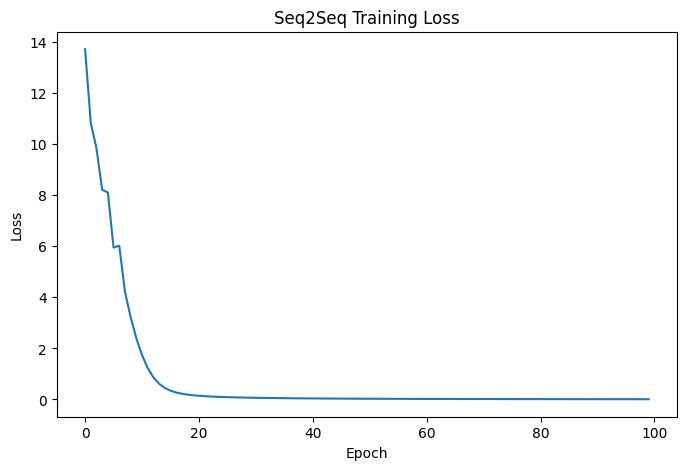

In [95]:
plt.figure(figsize=(8,5))
plt.plot(losses)

plt.title("Seq2Seq Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [97]:
def translate(sentence):

    seq2seq.eval()

    src = torch.tensor(
        encode(sentence, src_vocab)
    ).to(device)

    hidden = seq2seq.encoder(
        src.unsqueeze(1)
    )

    token = torch.tensor(
        [SOS_TOKEN]
    ).to(device)

    result = []

    for _ in range(10):

        output, hidden = seq2seq.decoder(
            token,
            hidden
        )

        token = output.argmax(dim=1)

        idx = token.item()

        if idx == EOS_TOKEN:
            break

        result.append(
            inv_tgt_vocab.get(
                idx,
                "<UNK>"
            )
        )

    return " ".join(result)

In [98]:
print(translate("i am happy"))
print(translate("good morning"))
print(translate("thank you"))

je suis heureux
bonjour
merci


In [99]:
print("seq2seq" in globals())
print("src_vocab" in globals())
print("tgt_vocab" in globals())
print("inv_tgt_vocab" in globals())

True
True
True
True


In [100]:
print("beam_search_translate" in globals())

False


In [101]:
def beam_search_translate(sentence, beam_width=3, max_len=10):

    seq2seq.eval()

    src = torch.tensor(
        encode(sentence, src_vocab)
    ).to(device)

    hidden = seq2seq.encoder(
        src.unsqueeze(1)
    )

    beams = [
        (
            [SOS_TOKEN],   # séquence
            hidden,        # état caché
            0.0            # score log-proba
        )
    ]

    for _ in range(max_len):

        candidates = []

        for seq, hidden_state, score in beams:

            last_token = seq[-1]

            if last_token == EOS_TOKEN:

                candidates.append(
                    (seq, hidden_state, score)
                )
                continue

            token = torch.tensor(
                [last_token]
            ).to(device)

            output, new_hidden = seq2seq.decoder(
                token,
                hidden_state
            )

            probs = torch.softmax(
                output,
                dim=1
            )

            top_probs, top_indices = torch.topk(
                probs,
                beam_width
            )

            for k in range(beam_width):

                next_token = (
                    top_indices[0][k]
                    .item()
                )

                next_prob = (
                    top_probs[0][k]
                    .item()
                )

                candidates.append(
                    (
                        seq + [next_token],
                        new_hidden,
                        score + np.log(next_prob + 1e-12)
                    )
                )

        beams = sorted(
            candidates,
            key=lambda x: x[2],
            reverse=True
        )[:beam_width]

    best_sequence = beams[0][0]

    words = []

    for token in best_sequence[1:]:

        if token == EOS_TOKEN:
            break

        words.append(
            inv_tgt_vocab.get(
                token,
                "<UNK>"
            )
        )

    return " ".join(words)

In [102]:
print(
    beam_search_translate(
        "i love you"
    )
)

je t aime


In [103]:
from nltk.translate.bleu_score import sentence_bleu

In [104]:
references = []
hypotheses = []

for src, tgt in pairs:

    prediction = translate(src)

    references.append(
        [tgt.split()]
    )

    hypotheses.append(
        prediction.split()
    )

scores = []

for ref, hyp in zip(
    references,
    hypotheses
):

    scores.append(
        sentence_bleu(
            ref,
            hyp
        )
    )

print(
    "BLEU moyen =",
    np.mean(scores)
)

BLEU moyen = 7.3280320185328215e-78


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

In [105]:
for src, tgt in pairs:

    pred = translate(src)

    print("Source :", src)
    print("Référence :", tgt)
    print("Prédiction :", pred)
    print("-"*40)

Source : i am happy
Référence : je suis heureux
Prédiction : je suis heureux
----------------------------------------
Source : i love you
Référence : je t aime
Prédiction : je t aime
----------------------------------------
Source : good morning
Référence : bonjour
Prédiction : bonjour
----------------------------------------
Source : thank you
Référence : merci
Prédiction : merci
----------------------------------------
Source : how are you
Référence : comment allez vous
Prédiction : comment allez vous
----------------------------------------


In [106]:
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

smooth = SmoothingFunction().method1

scores = []

for src, tgt in pairs:

    pred = translate(src)

    bleu = sentence_bleu(
        [tgt.split()],
        pred.split(),
        smoothing_function=smooth
    )

    scores.append(bleu)

print(
    "BLEU moyen (smoothed) =",
    np.mean(scores)
)

BLEU moyen (smoothed) = 0.4085359715157663


In [107]:
import pandas as pd

results_df = pd.DataFrame({
    "Modèle": ["RNN", "LSTM", "GRU", "Seq2Seq"],
    "Performance": [
        f"Accuracy = {rnn_acc:.4f}",
        f"Accuracy = {lstm_acc:.4f}",
        f"Accuracy = {gru_acc:.4f}",
        "BLEU = 0.4085"
    ]
})

display(results_df)

,Modèle,Performance
0,RNN,Accuracy = 0.7704
1,LSTM,Accuracy = 0.8126
2,GRU,Accuracy = 0.8794
3,Seq2Seq,BLEU = 0.4085


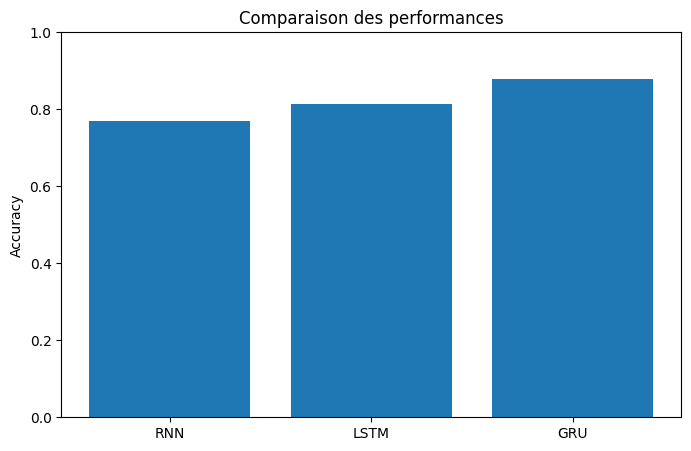

In [108]:
import matplotlib.pyplot as plt

models = ["RNN", "LSTM", "GRU"]
accuracies = [0.7704, 0.8126, 0.8794]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Comparaison des performances")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

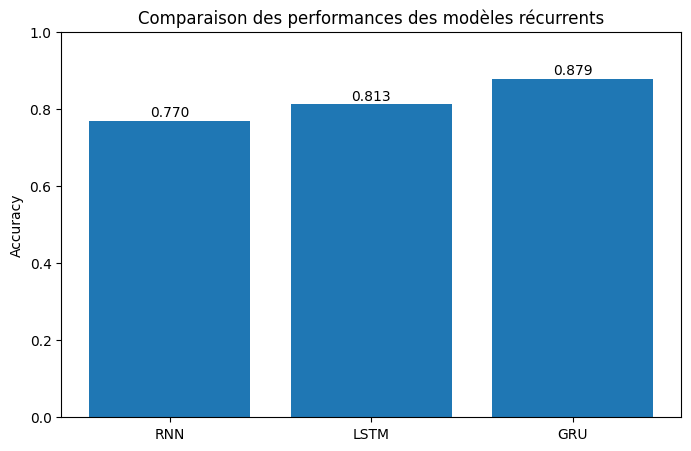

In [109]:
import matplotlib.pyplot as plt

models = ["RNN", "LSTM", "GRU"]
accuracies = [0.7704, 0.8126, 0.8794]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.title("Comparaison des performances des modèles récurrents")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.show()